### **Predicting Trading Signals Using Machine Learning**

**Objective**

This project focuses on predicting **trading decisions**:
- Buy (1)
- Sell (-1)
- Hold (0)

**Important:**

We are NOT predicting stock prices.  
We are predicting **trading signals** based on technical indicators.

**Workflow**

1. Load data  
2. Create indicators (MACD, RSI)  
3. Generate signals  
4. Train ML models  
5. Evaluate performance  

In [5]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [6]:
# Load Dataset

from google.colab import files
uploaded = files.upload()

Saving historical_stock_prices.csv to historical_stock_prices (1).csv


In [7]:
# load CSV file
df = pd.read_csv('historical_stock_prices.csv')

df.head()

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


Load historical stock data

In [8]:
# Data Preprocessing

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df.sort_index(inplace=True)

df.head()

,ticker,open,close,adj_close,low,high,volume
date,,,,,,,
1972-06-01,PFE,0.846354,0.859375,0.000628,0.846354,0.859375,2332800
1972-06-02,PFE,0.859375,0.848958,0.000620,0.846354,0.861979,1531200
1972-06-05,PFE,0.848958,0.846354,0.000618,0.841146,0.851562,2452800
1972-06-06,PFE,0.846354,0.864583,0.000631,0.843750,0.869792,2227200
1972-06-07,PFE,0.864583,0.864583,0.000631,0.851562,0.864583,979200


Convert date column to datetime

Set it as index

Sort data chronologically

In [9]:
# MACD Calculation

# EMA calculations
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

# MACD line
df['MACD'] = df['EMA12'] - df['EMA26']

# Signal line
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

df[['MACD', 'Signal_Line']].head()

,MACD,Signal_Line
date,,
1972-06-01,0.000000,0.000000
1972-06-02,-0.000831,-0.000166
1972-06-05,-0.001680,-0.000469
1972-06-06,-0.000872,-0.000550
1972-06-07,-0.000229,-0.000486


MACD = short-term trend − long-term trend

Signal line = smoothed MACD

Used to detect momentum changes

In [10]:
# MACD Trading Signals

df['MACD_signal'] = 0

df.loc[df['MACD'] > df['Signal_Line'], 'MACD_signal'] = 1   # Buy
df.loc[df['MACD'] < df['Signal_Line'], 'MACD_signal'] = -1  # Sell

MACD above signal → upward trend → Buy

MACD below signal → downward trend → Sell

In [11]:
# RSI Calculation

delta = df['close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

df[['RSI']].head()

,RSI
date,
1972-06-01,NaN
1972-06-02,0.000000
1972-06-05,0.000000
1972-06-06,64.390836
1972-06-07,64.390836


RSI measures overbought/oversold conditions

Range: 0 to 100

In [12]:
# RSI Signals

df['RSI_signal'] = 0

df.loc[df['RSI'] < 30, 'RSI_signal'] = 1   # Buy
df.loc[df['RSI'] > 70, 'RSI_signal'] = -1  # Sell

RSI < 30 → oversold → Buy

RSI > 70 → overbought → Sell

In [13]:
# Final Trading Signal

df['Final_Signal'] = 0

df.loc[(df['MACD_signal'] == 1) & (df['RSI_signal'] == 1), 'Final_Signal'] = 1
df.loc[(df['MACD_signal'] == -1) & (df['RSI_signal'] == -1), 'Final_Signal'] = -1

df[['MACD_signal', 'RSI_signal', 'Final_Signal']].head()

,MACD_signal,RSI_signal,Final_Signal
date,,,
1972-06-01,0,0,0
1972-06-02,-1,1,0
1972-06-05,-1,1,0
1972-06-06,-1,0,0
1972-06-07,1,0,0


Strong Buy → both indicators agree

Strong Sell → both indicators agree

Otherwise → Hold

In [14]:
# Handle Missing Values

df.dropna(inplace=True)

Remove rows with NaN values (caused by indicators)

In [15]:
# Feature & Target Selection

df["Signal"] = (df["close"].shift(-1) > df["close"]).astype(int)
X = df[['MACD', 'Signal_Line', 'RSI']]
y = df['Signal']

Features = indicators

Target = trading decision

In [16]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

No shuffle!

Time series data must preserve order

Past → Train

Future → Test

In [17]:
# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

Simple linear model

Good baseline

In [18]:
print(df["Signal"].value_counts())

Signal
0    524648
1    523926
Name: count, dtype: int64


In [19]:
train_test_split(X, y, test_size=0.2, shuffle=False)

[                MACD  Signal_Line        RSI
 date                                        
 1972-06-02 -0.000831    -0.000166   0.000000
 1972-06-05 -0.001680    -0.000469   0.000000
 1972-06-06 -0.000872    -0.000550  64.390836
 1972-06-07 -0.000229    -0.000486  64.390836
 1972-06-08 -0.000139    -0.000416  51.722242
 ...              ...          ...        ...
 2015-06-10  9.501896     8.037780  47.179554
 2015-06-10  6.952972     7.820818  48.006936
 2015-06-10  3.153639     6.887382  45.867565
 2015-06-10  2.262952     5.962496  49.091235
 2015-06-10 -0.851438     4.599709  45.563748
 
 [838859 rows x 3 columns],
                 MACD  Signal_Line        RSI
 date                                        
 2015-06-10 -3.153199     3.049128  45.805415
 2015-06-10 -4.275435     1.584215  47.163474
 2015-06-11 -1.962139     0.874944  53.688204
 2015-06-11 -3.760985    -0.052242  46.096698
 2015-06-11 -5.093974    -1.060588  46.177667
 ...              ...          ...        ...
 201

In [20]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

Ensemble model (many trees)

Handles non-linearity well

In [21]:
# SGDClassifier

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Robust df initialization and feature calculation START ---
# Load Dataset
df = pd.read_csv('historical_stock_prices.csv')

# Data Preprocessing
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# MACD Calculation
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# RSI Calculation
delta = df['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# Handle Missing Values
df.dropna(inplace=True)
# --- Robust df initialization and feature calculation END ---

# Feature & Target Selection (added for robustness)
df["Signal"] = (df["close"].shift(-1) > df["close"]).astype(int)
X = df[['MACD', 'Signal_Line', 'RSI']]
y = df['Signal']

# Check if X_train and y_train are defined. If not, perform the split.
# This assumes X and y are defined from previous cells (M4ZD6WpbRlcp has been executed).
try:
    # Accessing X_train and y_train will raise NameError if they don't exist
    _ = X_train
    _ = y_train
except NameError:
    # Re-run train_test_split to define X_train, X_test, y_train, y_test
    # This also assumes X and y are available in the kernel.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

svm = SGDClassifier(loss='hinge')  # behaves like linear SVM
svm.fit(X_train, y_train)

SGDClassifier()

Finds optimal boundary between classes

Works well with complex patterns

In [22]:
# Model Evaluation

for model in [lr, rf, svm]:
    preds = model.predict(X_test)
    print("Model:", model)
    print(classification_report(y_test, preds))

Model: LogisticRegression()
              precision    recall  f1-score   support

           0       0.77      0.66      0.71    104836
           1       0.70      0.81      0.75    104879

    accuracy                           0.73    209715
   macro avg       0.74      0.73      0.73    209715
weighted avg       0.74      0.73      0.73    209715

Model: RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.72      0.74      0.73    104836
           1       0.74      0.71      0.72    104879

    accuracy                           0.73    209715
   macro avg       0.73      0.73      0.73    209715
weighted avg       0.73      0.73      0.73    209715

Model: SGDClassifier()
              precision    recall  f1-score   support

           0       0.74      0.73      0.73    104836
           1       0.73      0.74      0.74    104879

    accuracy                           0.74    209715
   macro avg       0.74      0.74      0.74  

Metrics:

Accuracy → overall correctness

Precision → correctness of predicted signals

Recall → ability to find true signals

F1-score → balance

In [23]:
# Optimization (Random Forest)

rf_optimized = RandomForestClassifier(n_estimators=200, max_depth=10)
rf_optimized.fit(X_train, y_train)

preds = rf_optimized.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.73      0.77      0.75    104836
           1       0.75      0.71      0.73    104879

    accuracy                           0.74    209715
   macro avg       0.74      0.74      0.74    209715
weighted avg       0.74      0.74      0.74    209715



More trees → better learning

Max depth → prevents overfitting

In [28]:
# Use a smaller dataset
df_sample = df.sample(200000, random_state=42)

# Define features as a list of column names
features = ['MACD', 'Signal_Line', 'RSI']

X_sample = df_sample[features]
y_sample = df_sample["Signal"]

In [31]:
rf_optimized = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1
)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

scores = cross_val_score(rf, X_sample, y_sample, cv=3, n_jobs=-1)

print(scores.mean())

0.7404950059370545


Validates model on multiple splits

Gives more reliable performance estimate

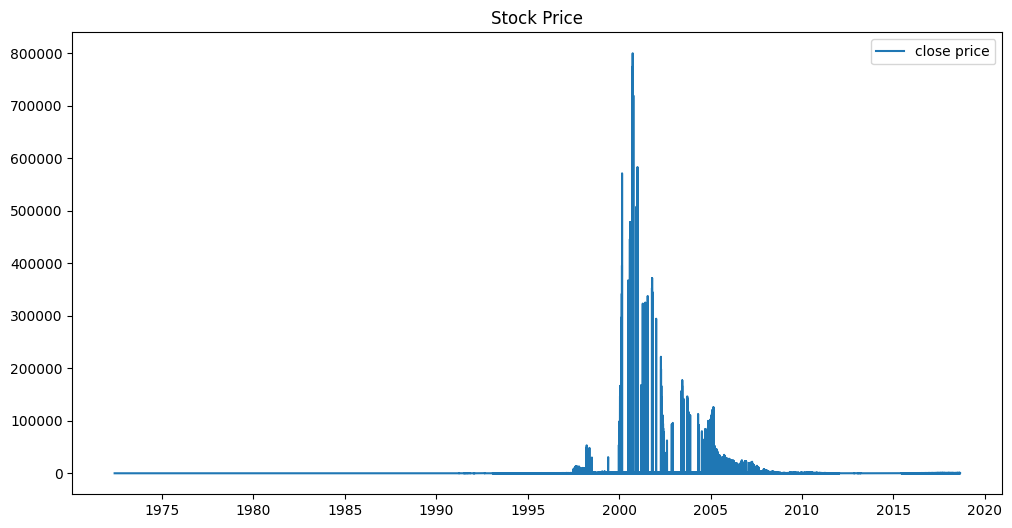

In [35]:
# Visualization

plt.figure(figsize=(12,6))
plt.plot(df['close'], label='close price')
plt.title('Stock Price')
plt.legend()
plt.show()

Helps understand price movement

### **Final Notes**

Key Takeaways

- We predicted trading signals, NOT prices
- Feature engineering is the most important step
- Random Forest usually performs best
- Time-series handling (no shuffle) is critical